In [1]:
# !python -m pip install -U python-woc pandas matplotlib
# please clear the output of this cell in your notebook before checking it in

In [ ]:
from woc.remote import WocMapsRemote
from tqdm import tqdm
import pandas as pd
# creates the client
woc = WocMapsRemote( base_url="https://worldofcode.org/api/")
# if you got an API key
# woc = WocMapsRemote( base_url="https://worldofcode.org/api/", api_key="woc-XXXXXX-YYYYYY" )

# Now for each of the ten projects you were assigned get commits, e.g.
projects = [
  'daducci_amico',
  'yangjasp_optimall',
  'anybotics_kindr',
  'scikit-fuzzy_scikit-fuzzy',
  'mhhennig_hs2',
  'bids-apps_rshrf',
  'juliastats_lasso.jl',
  'dcc-lab_pyhardwarelibrary',
  'cmillion_gphoton',
  'aim-uofa_adelaidet'
]
list_df_commits = []
for prj in projects:
  # Convert GitHub repository names to WoC V2412 project names
  prj = prj.lower().replace('/','_',2)
  commits = woc.get_values('p2c', prj)
  df = pd.DataFrame(commits, columns=["sha1"])
  df['project'] = prj
  list_df_commits.append(df)
df = pd.concat(list_df_commits)
#perhaps save the list (if no errors) so you do not need to retrieve them again
df.to_csv('eabbott9_df_commits.csv')
df.head(1)

,sha1,project
0,00534996cc67dc37a0406ba20f8d16a68fa3ff79,daducci_amico


In [ ]:
# If the number of commits its not very large, you can try to get them all at the same time,
# The max batch size is 10
import time
# let us first split df['sha1'] in chunks
chunks = [df['sha1'][x:x+10] for x in range(0, len(df), 10)]
commit_data = []

for chunk in tqdm(chunks): # iterate over the commits
  # res, err = woc.show_content_many('commit',chunk.to_list())

  # commit.tch returns the same data but faster
  res, err = woc.get_values_many('commit.tch',chunk.to_list())
  res = {k: v[0] for k, v in res.items()}  # this conversion is necessary because of the internal implementation

  # to walk around the rate limit
  time.sleep(1)

  if err: # check for errors
    print('Got Errors', err)

  for commit_sha, commit in res.items():

    # flatten commit objects
    commit_data.append({
          'commit': commit_sha,
          'tree': commit[0],
          'parent': list(commit[1]),
          'author': commit[2][0],
          'author_time': int(commit[2][1]),
          'author_tz': commit[2][2],
          'committer': commit[3][0],
          'committer_time': int(commit[3][1]),
          'committer_tz': commit[3][2],
          'message': commit[4],
    })

df_commit_data = pd.DataFrame(commit_data)
df_commit_data = df_commit_data.merge(df, left_on='commit', right_on='sha1')
df_commit_data.to_csv('eabbott9_df_commit_data.csv', index=False)
df_commit_data.head(2)

  0%|          | 0/652 [00:00<?, ?it/s]

  1%|          | 7/652 [00:07<10:56,  1.02s/it]

Got Errors {'231f31b8ddcbb2e79fd1466af9a612dfcfb459c9': 'Key 231f31b8ddcbb2e79fd1466af9a612dfcfb459c9 not found in /da5_fast/All.sha1c/commit_35.tch'}


 25%|██▌       | 164/652 [02:47<08:18,  1.02s/it]

Got Errors {'86db8a5ea3b6cd902bf2b406a61763eb6bb063a7': 'Key 86db8a5ea3b6cd902bf2b406a61763eb6bb063a7 not found in /da5_fast/All.sha1c/commit_6.tch'}


...

Got Errors {'2c5ab9c369d9119581869c1f1a1016582b1daa40': 'Key 2c5ab9c369d9119581869c1f1a1016582b1daa40 not found in /da5_fast/All.sha1c/commit_44.tch'}


 82%|████████▏ | 534/652 [09:03<01:59,  1.02s/it]

Got Errors {'586de90be1847ded96d7c50aef291b0ba5099ad9': 'Key 586de90be1847ded96d7c50aef291b0ba5099ad9 not found in /da5_fast/All.sha1c/commit_88.tch'}


100%|██████████| 652/652 [11:04<00:00,  1.02s/it]


,commit,tree,parent,author,author_time,author_tz,committer,committer_time,committer_tz,message,sha1,project
0,00534996cc67dc37a0406ba20f8d16a68fa3ff79,21b7f5309dc04f392df524bd61b459eab3a0817f,[d65239cc8bc5fe7da12ca365aaa552792b0bc0ce],nightwnvol <notte_94@hotmail.it>,1656677387,+0200,nightwnvol <notte_94@hotmail.it>,1656677387,+0200,refactor: rename methods and variables\n,00534996cc67dc37a0406ba20f8d16a68fa3ff79,daducci_amico
1,00c6ac9579f55819e5e800aba08f9cf18b314c0a,174834197983965595f4ce17e9b58a916be47070,[09cfbdda847232fd5b85f1cf00b4c5b8c711086f],Alessandro Daducci <alessandro.daducci@univr.it>,1638532643,+0100,Alessandro Daducci <alessandro.daducci@univr.it>,1638532643,+0100,Install information are stored (and taken from...,00c6ac9579f55819e5e800aba08f9cf18b314c0a,daducci_amico


In [4]:
# what does the first record looks like?
# commit  parents
v = commit_data[0]
# commit tree, [parent{s}], [author, unixtime, tz ], [ committer, unixtime, tz ], Commit_message ]
print(v)

{'commit': '00534996cc67dc37a0406ba20f8d16a68fa3ff79', 'tree': '21b7f5309dc04f392df524bd61b459eab3a0817f', 'parent': ['d65239cc8bc5fe7da12ca365aaa552792b0bc0ce'], 'author': 'nightwnvol <notte_94@hotmail.it>', 'author_time': 1656677387, 'author_tz': '+0200', 'committer': 'nightwnvol <notte_94@hotmail.it>', 'committer_time': 1656677387, 'committer_tz': '+0200', 'message': 'refactor: rename methods and variables\n'}


In [14]:
# Now that the data is retrieved, save it and commit to your GH fork
# First, we need to flatten info in order to export as csv
# our dataframe will have columns project,'commit, author, time, message'
new_columns = ['project', 'commit', 'author', 'time', 'message']
dfinf = df_commit_data.rename(columns={
    'author_time': 'time',
})[new_columns]


In [15]:
# check if it has the right content
dfinf.head(1)

,project,commit,author,time,message
0,daducci_amico,00534996cc67dc37a0406ba20f8d16a68fa3ff79,nightwnvol <notte_94@hotmail.it>,1656677387,refactor: rename methods and variables\n


In [23]:
#mode a means append, so you have all your projects in the same file
yournetid='eabbott9'
dfinf.to_csv(yournetid+'_project_summary.csv', index=False,sep=';', mode='a', header=False)

# Answers

### Table of the number of stars, number of forks, and the last commit date for each project


In [66]:
# defines project dataframes with information from GitHub
github_cols = ['Project', 'Stars', 'Forks', 'LastCommitDate']
github_stats = [
    ('daducci_amico', 130, 67, '12/17/2025'),
    ('yangjasp_optimall', 7, 2, '4/3/2026'),
    ('anybotics_kindr', 617, 207, '2/14/2025'),
    ('scikit-fuzzy_scikit-fuzzy', 877, 292, '8/25/2024'),
    ('mhhennig_hs2', 31, 19, '1/24/2025'),
    ('bids-apps_rshrf', 42, 15, '7/23/2026'),
    ('juliastats_lasso.jl', 147, 34, '7/28/2026'),
    ('dcc-lab_pyhardwarelibrary', 12, 3, '8/12/2026'),
    ('cmillion_gphoton', 21, 10, '2/13/2025'),
    ('aim-uofa_adelaidet', 3500, 653, '8/22/2024'),
]
project_level_df = pd.DataFrame(github_stats, columns=github_cols)

print(project_level_df.to_markdown(index=False))
print()

| Project                   |   Stars |   Forks | LastCommitDate   |
|:--------------------------|--------:|--------:|:-----------------|
| daducci_amico             |     130 |      67 | 12/17/2025       |
| yangjasp_optimall         |       7 |       2 | 4/3/2026         |
| anybotics_kindr           |     617 |     207 | 2/14/2025        |
| scikit-fuzzy_scikit-fuzzy |     877 |     292 | 8/25/2024        |
| mhhennig_hs2              |      31 |      19 | 1/24/2025        |
| bids-apps_rshrf           |      42 |      15 | 7/23/2026        |
| juliastats_lasso.jl       |     147 |      34 | 7/28/2026        |
| dcc-lab_pyhardwarelibrary |      12 |       3 | 8/12/2026        |
| cmillion_gphoton          |      21 |      10 | 2/13/2025        |
| aim-uofa_adelaidet        |    3500 |     653 | 8/22/2024        |



| Project                   |   Stars |   Forks | LastCommitDate   |
|:--------------------------|--------:|--------:|:-----------------|
| daducci_amico             |     130 |      67 | 12/17/2025       |
| yangjasp_optimall         |       7 |       2 | 4/3/2026         |
| anybotics_kindr           |     617 |     207 | 2/14/2025        |
| scikit-fuzzy_scikit-fuzzy |     877 |     292 | 8/25/2024        |
| mhhennig_hs2              |      31 |      19 | 1/24/2025        |
| bids-apps_rshrf           |      42 |      15 | 7/23/2026        |
| juliastats_lasso.jl       |     147 |      34 | 7/28/2026        |
| dcc-lab_pyhardwarelibrary |      12 |       3 | 8/12/2026        |
| cmillion_gphoton          |      21 |      10 | 2/13/2025        |
| aim-uofa_adelaidet        |    3500 |     653 | 8/22/2024        |


### Table of the number of commits, the number of authors, and max and min time for each project

In [70]:
# generates partial markdown table for project, author, max_time, and min_time
num_commits = []
num_authors = []
max_time = []
min_time = []
for project in projects:
    project_df = dfinf[dfinf['project'] == project]
    num_commits.append(len(project_df))
    num_authors.append(project_df['author'].nunique())
    max_time.append(project_df['time'].max())
    min_time.append(project_df['time'].min())
project_level_df['NumCommits'] = num_commits
project_level_df['NumAuthors'] = num_authors
project_level_df['MaxTime'] = max_time
project_level_df['MinTime'] = min_time

print(project_level_df.to_markdown(index=False))
print()

| Project                   |   Stars |   Forks | LastCommitDate   |   NumCommits |   NumAuthors |    MaxTime |    MinTime |
|:--------------------------|--------:|--------:|:-----------------|-------------:|-------------:|-----------:|-----------:|
| daducci_amico             |     130 |      67 | 12/17/2025       |          618 |           46 | 1768769157 | 1412688947 |
| yangjasp_optimall         |       7 |       2 | 4/3/2026         |          564 |            3 | 1775254108 | 1600887255 |
| anybotics_kindr           |     617 |     207 | 2/14/2025        |          864 |           65 | 1741698942 | 1381244746 |
| scikit-fuzzy_scikit-fuzzy |     877 |     292 | 8/25/2024        |          673 |           68 | 1731068774 | 1363667243 |
| mhhennig_hs2              |      31 |      19 | 1/24/2025        |          614 |           30 | 1737717436 | 1501257793 |
| bids-apps_rshrf           |      42 |      15 | 7/23/2026        |          553 |           31 | 1775331973 | 1468998858 |


| Project                   |   Stars |   Forks | LastCommitDate   |   NumCommits |   NumAuthors |    MaxTime |    MinTime |
|:--------------------------|--------:|--------:|:-----------------|-------------:|-------------:|-----------:|-----------:|
| daducci_amico             |     130 |      67 | 12/17/2025       |          618 |           46 | 1768769157 | 1412688947 |
| yangjasp_optimall         |       7 |       2 | 4/3/2026         |          564 |            3 | 1775254108 | 1600887255 |
| anybotics_kindr           |     617 |     207 | 2/14/2025        |          864 |           65 | 1741698942 | 1381244746 |
| scikit-fuzzy_scikit-fuzzy |     877 |     292 | 8/25/2024        |          673 |           68 | 1731068774 | 1363667243 |
| mhhennig_hs2              |      31 |      19 | 1/24/2025        |          614 |           30 | 1737717436 | 1501257793 |
| bids-apps_rshrf           |      42 |      15 | 7/23/2026        |          553 |           31 | 1775331973 | 1468998858 |
| juliastats_lasso.jl       |     147 |      34 | 7/28/2026        |          368 |           28 | 1762100330 | 1396912911 |
| dcc-lab_pyhardwarelibrary |      12 |       3 | 8/12/2026        |          724 |           16 | 1758678540 | 1531878900 |
| cmillion_gphoton          |      21 |      10 | 2/13/2025        |          949 |           12 | 1762296960 | 1394033282 |
| aim-uofa_adelaidet        |    3500 |     653 | 8/22/2024        |          573 |           55 | 1725492812 | 1579751240 |


### Visualization of the commit timestamps

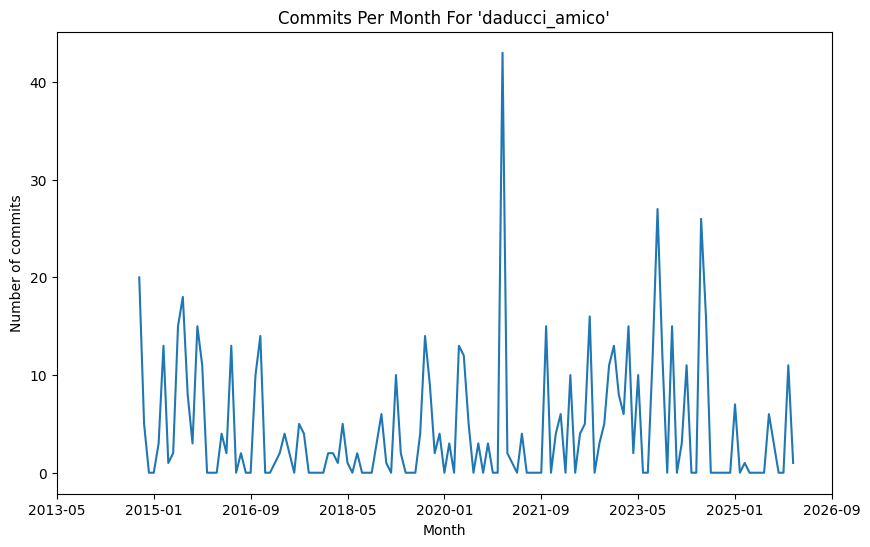

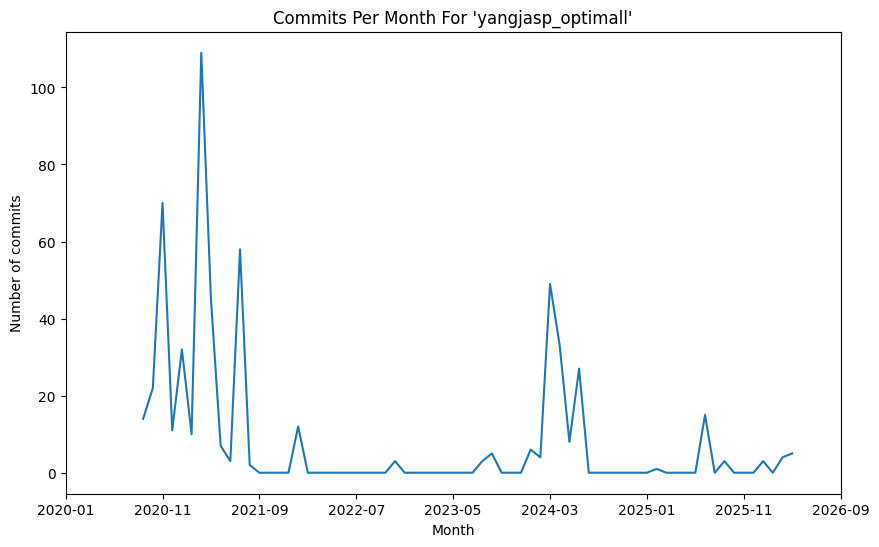

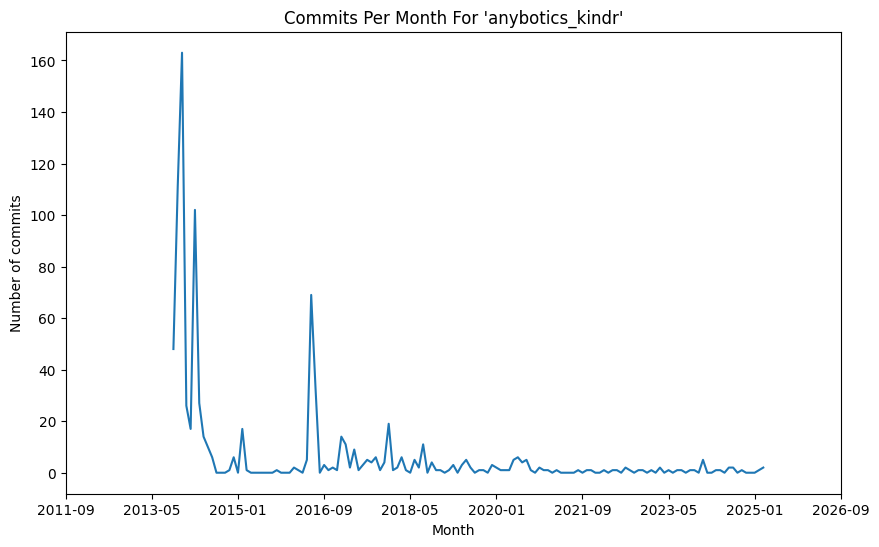

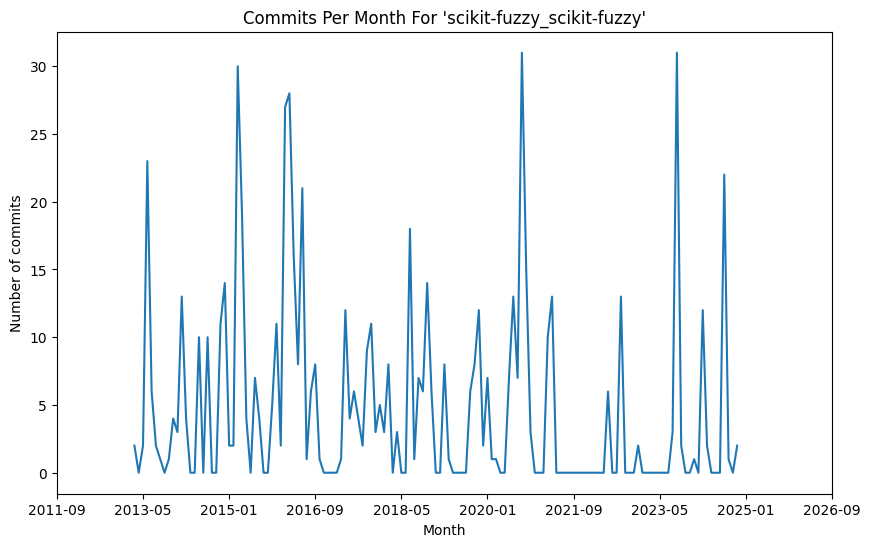

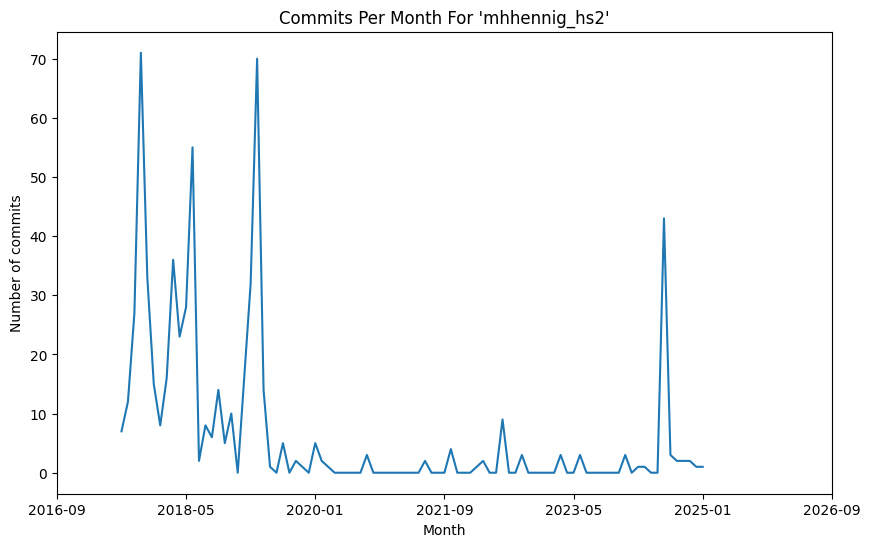

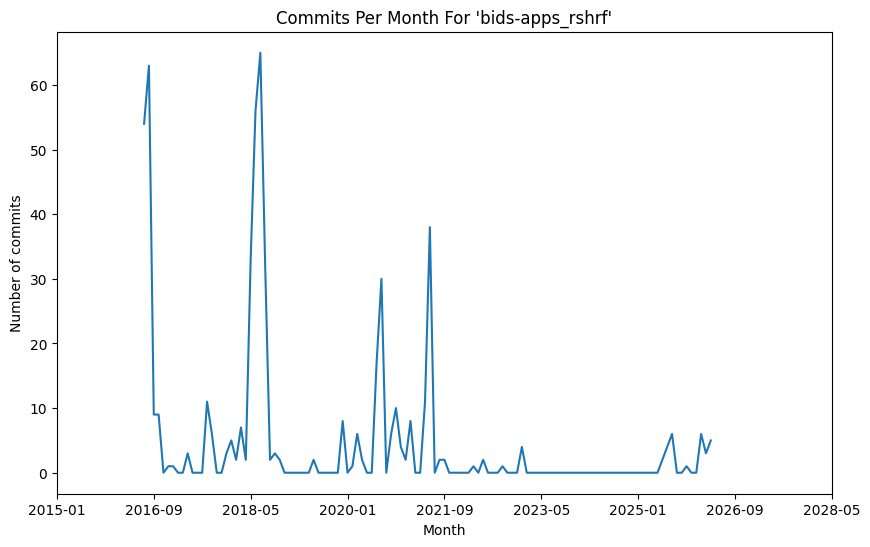

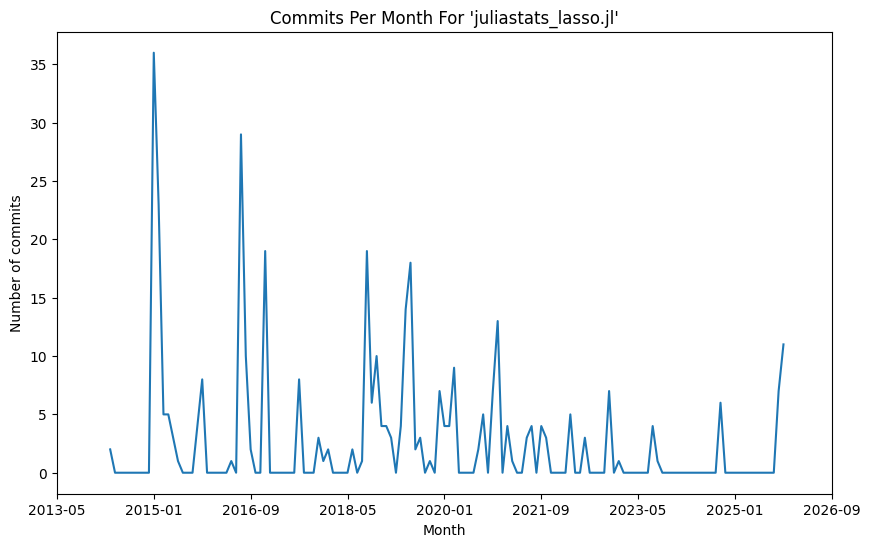

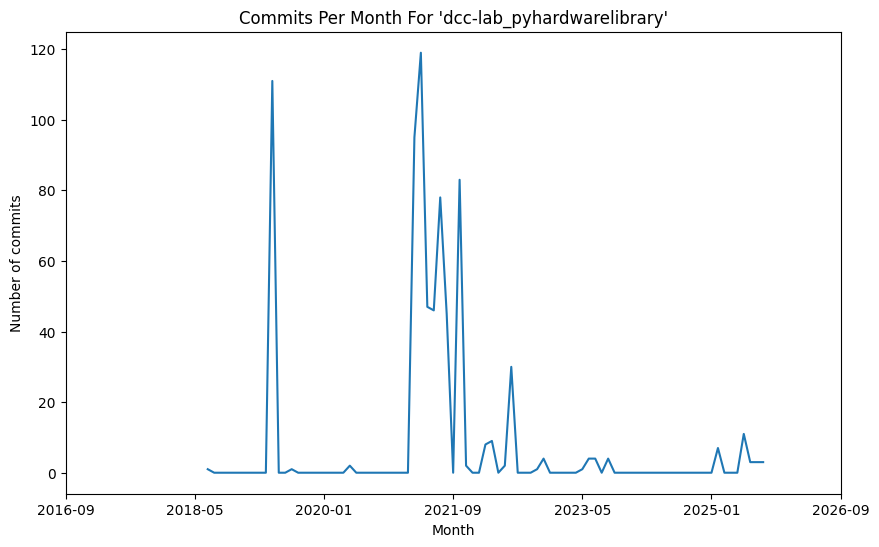

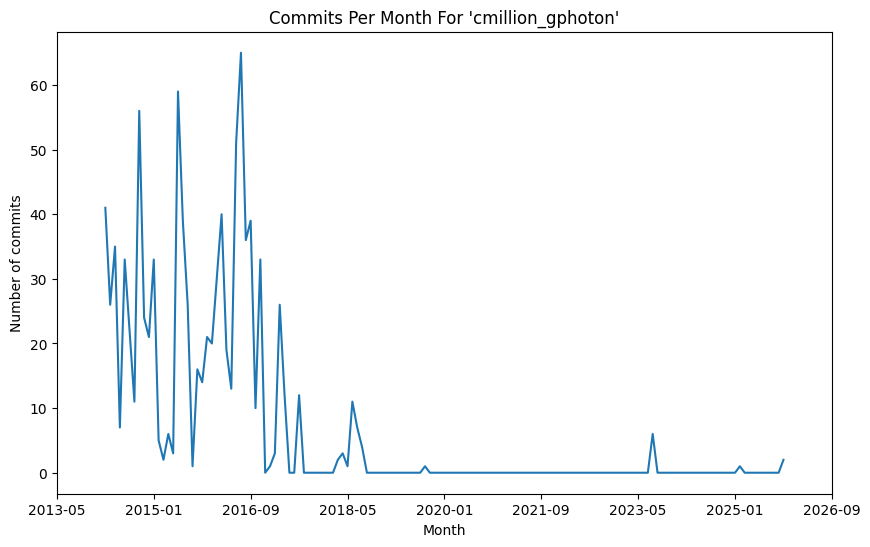

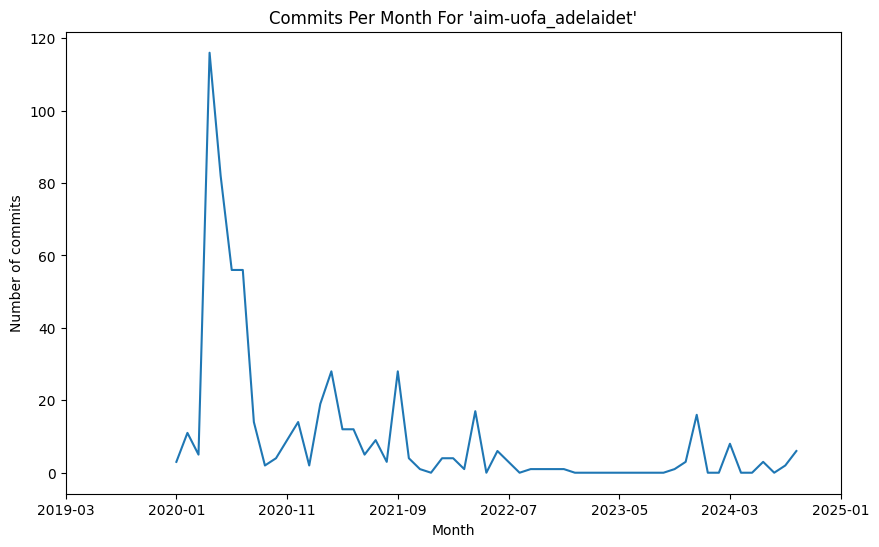

In [71]:
# creates graphs and CSVs of inactivity
from datetime import datetime
from zoneinfo import ZoneInfo
import matplotlib.pyplot as plt

def to_month_stamp(month_idx):
    return f"{month_idx // 12}-{month_idx % 12 + 1 :02d}"

project_freqs = {}

for project in projects:
    # compute month frequencies
    project_df = dfinf[dfinf['project'] == project]
    times = project_df['time'].tolist()
    month_freqs = {}
    min_month = 0xFFFF_FFFF
    max_month = 0
    for timestamp in times:
        dt = datetime.fromtimestamp(timestamp, ZoneInfo('US/Eastern'))
        month_idx = 12*dt.year + dt.month - 1
        if month_idx < min_month: min_month = month_idx
        if month_idx > max_month: max_month = month_idx
        if month_idx in month_freqs: month_freqs[month_idx] += 1
        else: month_freqs[month_idx] = 1
    months = range(min_month, max_month + 1)
    freqs = [month_freqs[month_idx] if month_idx in month_freqs else 0 for month_idx in months]

    # add to global variable
    project_freqs[project] = (months, freqs)

    # save to CSV
    file = open(f"eabbott9_commits_timeseries_{project}.csv", "w")
    file.write("month,# commits\n")
    for month, freq in zip(months, freqs):
        file.write(f"{to_month_stamp(month)},{freq}\n")
    file.close()

    # plot result
    plt.figure(figsize=(10, 6))
    plt.title(f"Commits Per Month For \'{project}\'")
    plt.plot(months, freqs)
    locs, labels = plt.xticks()
    plt.xticks(locs, [to_month_stamp(int(label.get_text())) for label in labels])
    plt.xlabel("Month")
    plt.ylabel("Number of commits")
    plt.show()
    plt.close()



### Identifying the Longest Inactivity Gap

In [73]:
# computes maximum gap start, end, length; number of gaps, number of commits after last gap
max_gap_lengths = []
max_gap_starts = []
max_gap_ends = []
nums_gaps = []
nums_commits_after_gaps = []
for project in projects:
    months, freqs = project_freqs[project]
    num_zeros = 0
    max_gap_len = 0
    max_gap_start = -1
    max_gap_end = -1
    num_gaps = 0
    num_commits_after_gap = 0
    for i in range(len(freqs)):
        # if month had commit
        if freqs[i] != 0:
            num_commits_after_gap += 1
            num_zeros = 0

        # if month had no commit
        else:
            num_zeros += 1
            num_commits_after_gap = 0

            # if start of gap
            if num_zeros == 3:
                num_gaps += 1

            # if in gap and it is biggest gap
            if num_zeros >= 3 and num_zeros > max_gap_len:
                max_gap_len = num_zeros
                max_gap_start = months[i - num_zeros + 1]
                max_gap_end = months[i]

    # store to global lists
    max_gap_lengths.append(max_gap_len)
    max_gap_starts.append(to_month_stamp(max_gap_start))
    max_gap_ends.append(to_month_stamp(max_gap_end))
    nums_gaps.append(num_gaps)
    nums_commits_after_gaps.append(num_commits_after_gap)

# update project level dataframe
project_level_df['LongestGapLength'] = max_gap_lengths
project_level_df['LongestGapStart'] = max_gap_starts
project_level_df['LongestGapEnd'] = max_gap_ends
project_level_df['NumberOfGapsInTimeline'] = nums_gaps
project_level_df['NumCommitsAfterLastGap'] = nums_commits_after_gaps

# specify activity patterns
activity_patterns = [
    "irregular", "declining + irregular", "steady", "irregular", "irregular",
    "declining + irregular", "u-shaped + irregular", "declining + irregular", "steady", "irregular"
]
project_level_df['ActivityPatterns'] = activity_patterns

# output project stats to CSV
project_level_df.to_csv("eabbott9_project_stats.csv", index=False)

# print to screen markdown table
print(project_level_df.to_markdown(index=False))
print()


| Project                   |   Stars |   Forks | LastCommitDate   |   NumCommits |   NumAuthors |    MaxTime |    MinTime |   LongestGapLength | LongestGapStart   | LongestGapEnd   |   NumberOfGapsInTimeline |   NumCommitsAfterLastGap | ActivityPatterns      |
|:--------------------------|--------:|--------:|:-----------------|-------------:|-------------:|-----------:|-----------:|-------------------:|:------------------|:----------------|-------------------------:|-------------------------:|:----------------------|
| daducci_amico             |     130 |      67 | 12/17/2025       |          618 |           46 | 1768769157 | 1412688947 |                  5 | 2024-08           | 2024-12         |                        7 |                        2 | irregular             |
| yangjasp_optimall         |       7 |       2 | 4/3/2026         |          564 |            3 | 1775254108 | 1600887255 |                  9 | 2022-02           | 2022-10         |                        7 |    

| Project                   |   Stars |   Forks | LastCommitDate   |   NumCommits |   NumAuthors |    MaxTime |    MinTime |   LongestGapLength | LongestGapStart   | LongestGapEnd   |   NumberOfGapsInTimeline |   NumCommitsAfterLastGap | ActivityPatterns      |
|:--------------------------|--------:|--------:|:-----------------|-------------:|-------------:|-----------:|-----------:|-------------------:|:------------------|:----------------|-------------------------:|-------------------------:|:----------------------|
| daducci_amico             |     130 |      67 | 12/17/2025       |          618 |           46 | 1768769157 | 1412688947 |                  5 | 2024-08           | 2024-12         |                        7 |                        2 | irregular             |
| yangjasp_optimall         |       7 |       2 | 4/3/2026         |          564 |            3 | 1775254108 | 1600887255 |                  9 | 2022-02           | 2022-10         |                        7 |                        2 | declining + irregular |
| anybotics_kindr           |     617 |     207 | 2/14/2025        |          864 |           65 | 1741698942 | 1381244746 |                  6 | 2015-04           | 2015-09         |                        5 |                        2 | steady                |
| scikit-fuzzy_scikit-fuzzy |     877 |     292 | 8/25/2024        |          673 |           68 | 1731068774 | 1363667243 |                 12 | 2021-05           | 2022-04         |                        7 |                        1 | irregular             |
| mhhennig_hs2              |      31 |      19 | 1/24/2025        |          614 |           30 | 1737717436 | 1501257793 |                  8 | 2020-10           | 2021-05         |                        6 |                        7 | irregular             |
| bids-apps_rshrf           |      42 |      15 | 7/23/2026        |          553 |           31 | 1775331973 | 1468998858 |                 28 | 2023-02           | 2025-05         |                        7 |                        3 | declining + irregular |
| juliastats_lasso.jl       |     147 |      34 | 7/28/2026        |          368 |           28 | 1762100330 | 1396912911 |                 12 | 2023-10           | 2024-09         |                       12 |                        2 | u-shaped + irregular  |
| dcc-lab_pyhardwarelibrary |      12 |       3 | 8/12/2026        |          724 |           16 | 1758678540 | 1531878900 |                 16 | 2023-10           | 2025-01         |                        7 |                        4 | declining + irregular |
| cmillion_gphoton          |      21 |      10 | 2/13/2025        |          949 |           12 | 1762296960 | 1394033282 |                 46 | 2019-10           | 2023-07         |                        5 |                        1 | steady                |
| aim-uofa_adelaidet        |    3500 |     653 | 8/22/2024        |          573 |           55 | 1725492812 | 1579751240 |                  9 | 2023-01           | 2023-09         |                        1 |                        2 | irregular             |


### Interpretation

Many of the projects started with batches of many commits, only to dwindle to the rare batches of a few commits. Only a few projects actually have consistent batches of commits. Only one project saw its highest number of commits in one month after the beginning of its lifetime; all the other projects had their maximums in the beginning.

| Project | Number of Gaps |
| - | - |
| daducci_amico | 7 |
| yangjasp_optimall | 7 |
| anybotics_kindr | 5 |
| scikit-fuzzy_scikit-fuzzy | 7 |
| mhhennig_hs2 | 6 |
| bids-apps_rshrf | 7 |
| juliastats_lasso.jl | 12 |
| dcc-lab_pyhardwarelibrary | 7 |
| cmillion_gphoton | 5 |
| aim-uofa_adelaide | 1 |

### Examining Commits Before and After the Gap

In [105]:
prepost_commits = pd.DataFrame(columns=dfinf.columns)

def from_month_stamp(month_stamp):
    splitted = month_stamp.split("-")
    return int(splitted[0])*12 + int(splitted[1])

for project in projects:
    gap_start = from_month_stamp(project_level_df[project_level_df['Project'] == project]['LongestGapStart'].iloc[0])
    gap_end = from_month_stamp(project_level_df[project_level_df['Project'] == project]['LongestGapEnd'].iloc[0])

    # for each commit...
    project_df = dfinf[dfinf['project'] == project].copy().sort_values('time')
    for i in range(len(project_df)):
        timestamp = project_df.iloc[i][['time']]['time']
        dt = datetime.fromtimestamp(timestamp, ZoneInfo('US/Eastern'))
        month_idx = dt.year * 12 + dt.month - 1

        # if first commit after gap
        if month_idx > gap_end:
            num_pre = min(10, i-1)
            num_post = min(10, len(project_df)-i)
            pre_commits = project_df.iloc[i-num_pre:i].assign(PreOrPost='Pre')
            post_commits = project_df.iloc[i:i+num_post].assign(PreOrPost='Post')
            prepost_commits = pd.concat([prepost_commits, pre_commits, post_commits])
            break

# output results to CSV
prepost_commits.to_csv("eabbott9_project_gap_commits.csv", index=False)

# output results to readable format
for project in projects:
    project_df = prepost_commits[prepost_commits['project'] == project]
    pre_messages = [message.strip() for message in project_df[project_df['PreOrPost'] == 'Pre']['message'].to_list()]
    post_messages = [message.strip() for message in project_df[project_df['PreOrPost'] == 'Post']['message'].to_list()]
    print(f"{project}:")
    print("\tPre:")
    for message in pre_messages:
        to_print = message.split("\n")[0]
        print(f"\t\t{to_print}")
    print("\tPost:")
    for message in post_messages:
        to_print = message.split("\n")[0]
        print(f"\t\t{to_print}")

daducci_amico:
	Pre:
		docs: update CHANGELOG.md
		Merge pull request #192 from daducci/release/v2.0.3
		Merge 9a6b9f0bc58c252771142acab01b659bea55abb6 into df540093b60240c38a6ff2ea4ceb1181c4f3e936
		fix: UserWarning from dipy.core.gradients.gradient_table
		build: update numpy dependency; bump to v2.1.0
		docs: update CHANGELOG.md
		ci: add cp313 wheels; bump cibuildwheel to v2.22.0
		ci: bump macos x86_64 runners to v13
		ci: bump macos runner to v13
		Merge pull request #197 from daducci/release/v2.1.0
	Post:
		Merge 9a6b9f0bc58c252771142acab01b659bea55abb6 into 98a772b240e1cd67a26a17f47f7f7738bda41b73
		Update README.md
		Replaced get_distribution function to retrieve version
		Updated version and CHANGELOG
		Merge pull request #205 from daducci/204-deprecation-warning-replace-pkg_resources-in-amicocorepy-with-importlibmetadata
		Merge 9a6b9f0bc58c252771142acab01b659bea55abb6 into 7183ee098f400d08e68be097c170ec078e969295
		Merge 385e47d5ed1fc3ac411f5a000575ba616f7fb72a into 7183ee0

In [107]:
# defines two most common themes for commits pre and post largest gaps
# project -> (pre_themes, post_themes)
project_commit_themes = {
    'daducci_amico': (["release", "dependency"], ["release", "bug"]),
    'yangjasp_optimall': (["release", "documentation"], ["feature", "release"]),
    'anybotics_kindr': (["bug", "documentation"], ["dependency", "release"]),
    'scikit-fuzzy_scikit-fuzzy': (["dependency", "documentation"], ["dependency", "documentation"]),
    'mhhennig_hs2': (["feature", "bug"], ["dependency", "release"]),
    'bids-apps_rshrf': (["deployment", "documentation"], ["bug", "maintenance"]),
    'juliastats_lasso.jl': (["feature", "release"], ["dependency", "release"]),
    'dcc-lab_pyhardwarelibrary': (["feature", "documentation"], ["bug", "maintenance"]),
    'cmillion_gphoton': (["documentation", "feature"], ["build", "documentation"]),
    'aim-uofa_adelaidet': (["bug", "dependency"], ["documentation", "bug"])
}

pre_themes = [str(project_commit_themes[project][0]) for project in projects]
post_themes = [str(project_commit_themes[project][1]) for project in projects]

project_level_df['BeforeThemes'] = pre_themes
project_level_df['AfterThemes'] = post_themes
project_level_df.to_csv("eabbott9_project_stats.csv", index=False)

### Interpreting the Gaps

In [ ]:
# defines analyses for the different projects' biggest gaps
# project -> (HypothesizedGapReason, HasRecovered, WhyRecovered, WhoRecovered)
project_gap_hypotheses = {
    'daducci_amico': (
        "A pull request was merged right before the gap: \"Merge pull request #197 from daducci/release/v2.1.0\". It's possible that slow work was still being performed during the gap.",
        True,
        "Several pull requests were merged, suggesting slow work was being performed and submitted all at once.",
        "A common developer Paul McCarthy <pauldmccarthy@gmail.com> started the recovery, but the uncommon Alessandro Daducci <alessandro.daducci@univr.it> continued it."
    ),
    'yangjasp_optimall': (
        "A major version was released right before the gap: \"Version 0.1.2 update\". Another version update for 0.1.3 was released at the end of the gap. All of the AfterCommits and BeforeCommits were made by yangjasp, so maybe the gap was actually how long it took to make the new version.",
        True,
        "Only one batch of requests followed this gap, and a gap followed shortly afterwards. However, maintenance requests have been consistent since.",
        "The same developer recovered the project."
    ),
    'anybotics_kindr': (
        "Only 4 developers lead the BeforeCommits, while 5 newer developers picked up the project with pull requests for the AfterCommits. There were also spikes surrounding the gap, so it's possible the original developers abandonded the project and the newer developers started grinding out features.",
        True,
        "Newer developers picked up the project with merged pull requests.",
        "Those who recovered the project were not the same as the original developers. Only one of the 10 AfterCommits were from an old developer."
    ),
    'scikit-fuzzy_scikit-fuzzy': (
        "Four of the five commits before the gap included the term \"GitWash\", suggesting a large amount of work was poured into the feature. Most of the commits were made by two people with the same last name, suggesting it may be a project worked on by two siblings. After the large amount of work, they may have decided to take a break from the project.",
        True,
        "The same two maybe-siblings recovered the project, possibly because they had newfound time or had taken a long enough break.",
        "Those who recovered the project were the same as those who had been working on it shortly before the gap."
    ),
    'mhhennig_hs2': (
        "The COVID-19 pandemic started around the time of this gap (2020-10).",
        True,
        "Many small improvements were added, with half of them being build-related commits.",
        "Matthias H Hennig was found many times in both the BeforeCommits and AfterCommits, meaning it's likely the same team of developers."
    ),
    'bids-apps_rshrf': (
        "DemirEgeOrtac made two large commits immediately before the gap. Half of the AfterCommits were labeled \"minor changes\", suggesting the large commits may have justified a lull in commits.",
        False,
        "No significant batches of commits were made since the gap.",
        "N/A"
    ),
    'juliastats_lasso.jl': (
        "A couple of testing commits were made just before a couple of release commits; after these four commits, the gap started. The gap, then, was probably just another natural gap between versions. The second AfterCommit was a release commit as well, suggesting the gap was actually a period of work.",
        True,
        "Mohamed Tarek recovered the project on their own, with commit-adding bots like \"CompatHelper\" fluffing the commit count.",
        "Mohamed Tarek was not seen in the BeforeCommit window at all."
    ),
    'dcc-lab_pyhardwarelibrary': (
        "Out of the total 20 BeforeCommits and AfterCommits, Daniel Côté made 19 of them. The disproportionate authorship implies a heavy reliance on a single developer. It's possible the developer became burned out or chose a project for their small team of close to 1. Once the project was mostly finished, commit frequency plummetted.",
        False,
        "Only a handful of small, maintenance commits have been made since the gap.",
        "N/A"
    ),
    'cmillion_gphoton': (
        "A release commit (v1.28.9) was made shortly before the gap. Only three commits were made after the large gap--all of them for documentation--, indicating the project may be archived or abandonded.",
        False,
        "Only three commits were made since the end of the gap.",
        "N/A"
    ),
    'aim-uofa_adelaidet': (
        "The commits just before the gap were only for updating pillow as a dependency, and the ones before that were small changes like replacing a for loop with str.join. This implies the project was essentially complete only needs rare maintenance commits.",
        True,
        "Likely needed small documentation and dependency updates.",
        "Entirely different developers between AfterCommits and BeforeCommits"
    )
}

# add to project statistics
cols_to_add = ["HypothesizedGapReason", "HasRecovered", "WhyRecovered", "WhoRecovered"]
for i in range(len(cols_to_add)):
    project_level_df[cols_to_add[i]] = [project_gap_hypotheses[project][i] for project in projects]

# save project statistics to CSV
project_level_df.to_csv("eabbott9_project_stats.csv", index=False)

### Checking Current Project Status

In [119]:
# looked at GitHub for active repos with commits younger than 6 months
active_repos = set([
    'bids-apps_rshrf',
    'juliastats_lasso.jl',
    'dcc-lab_pyhardwarelibrary'
])
is_active = [project in active_repos for project in projects]
project_level_df['CurrentStatus'] = is_active

# compute ten most recent commits, readable output
for project in projects:
    # for each commit...
    project_df = dfinf[dfinf['project'] == project].copy().sort_values('time', ascending=False)
    messages = project_df['message'].iloc[:min(10, len(project_df))].to_list()
    print(f"{project}:")
    for message in messages:
        to_print = message.split("\n")[0]
        print(f"\t{to_print}")
    

daducci_amico:
	Merge 9a6b9f0bc58c252771142acab01b659bea55abb6 into a0c510e61445c6fc643ab5ac015ca67084cd05c4
	Increase timeout for arm64 compilation to 1000 minutes
	Update macOS version in OpenBLAS compile workflow
	Update macOS version in build wheels workflow
	Merge pull request #212 from daducci/fix/ensure_binary_mask
	Ensure the input binary mask is actually binary
	Merge 296a296e9fa49428d215f3d735ff8b15f7ff42dc into 7c92a770d992961aac7ba9782bde04159ecafdfd
	docs: update CHANGELOG.md
	fix: remove isExvivo parameter from CylinderZeppelinBall model
	Merge pull request #208 from daducci/fix_binary_mask
yangjasp_optimall:
	remove
	remove
	remove check
	Update test
	Update Cran comments
	Update rhub setup
	Wright III algorithm default set
	Wright algorithm III and improvements
	Wright algorithm improvements
	update for version 1.3.1
anybotics_kindr:
	Merge 63cacf3ba44193f91367be853de094e0e89668a6 into 32800890d546e306f73c3ee3091fb6903452f925
	Merge remote-tracking branch 'upstream/mast

In [120]:
# defining themes for latest commits for each project
project_last_commit_themes = {
    'daducci_amico': ["bug", "build"],
    'yangjasp_optimall': ["feature", "maintenance"],
    'anybotics_kindr': ["release", "feature"],
    'scikit-fuzzy_scikit-fuzzy': ["bug", "release"],
    'mhhennig_hs2': ["feature", "bug"],
    'bids-apps_rshrf': ["bug", "dependency"],
    'juliastats_lasso.jl': ["dependency", "build"],
    'dcc-lab_pyhardwarelibrary': ["bug", "build"],
    'cmillion_gphoton': ["documentation", "feature"],
    'aim-uofa_adelaidet': ["feature", "documentation"]
}

last_commit_themes = [str(project_last_commit_themes[project]) for project in projects]

project_level_df['RecentThemes'] = last_commit_themes
project_level_df.to_csv("eabbott9_project_stats.csv", index=False)

### Writing Reflections

In [ ]:
# Defining 2-4 sentence summaries of reflections
project_reflections_dict = {
    'daducci_amico': "",
    'yangjasp_optimall': "",
    'anybotics_kindr': "",
    'scikit-fuzzy_scikit-fuzzy': "",
    'mhhennig_hs2': "",
    'bids-apps_rshrf': "",
    'juliastats_lasso.jl': "",
    'dcc-lab_pyhardwarelibrary': "",
    'cmillion_gphoton': "",
    'aim-uofa_adelaidet': ""
}

project_reflections = [project_reflections[project] for project in projects]

project_level_df['Notes'] = project_reflections
project_level_df.to_csv("eabbott9_project_stats.csv", index=False)